In [ ]:
#import required libraries

import pandas as pd            #for data manipulation
import numpy as np             # for  numerical operations
import matplotlib.pyplot as plt  # for  plotting graphs
import seaborn as sns           # for advanced visulaizations




In [7]:
# 2. Load dataset into dataframe
df= pd.read_csv("C:/Users/Ruchi/Downloads/Dataset_Predict The Fare Amount Of Future Rides Using Regression Analysis/uber.csv")

#display first 5 rows to understand struture
print("First 5 rows of datset:")
print(df.head())

First 5 rows of datset:
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647      

In [8]:
#3. Understand Dataset Structure

# display dataset information(columns, datatypes, null values)
print("\nDataset Information:")
df.info()

#display statistical  summary of numerical columns
print("\nStatistical Summary:")
print(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB

Statistical Summary:
         Unnamed: 0    fare_amount  pickup_longitude  pickup_latitude  \
count  2.000000e+05  200000.000000     200000.000000    200000.000000   
mean   2.771250e+07      11.359955        -72.527638        39.935885   
std    1.601382e+07      

In [9]:
# 4. Check missing values

#count missing values in each column
print("n\Missing Values: ")
print(df.isnull().sum())


n\Missing Values: 
Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


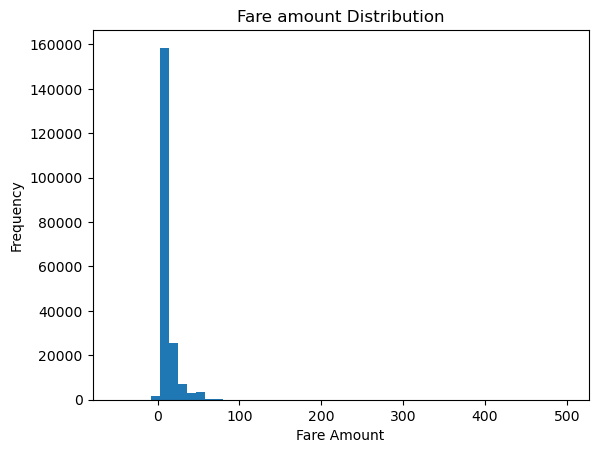

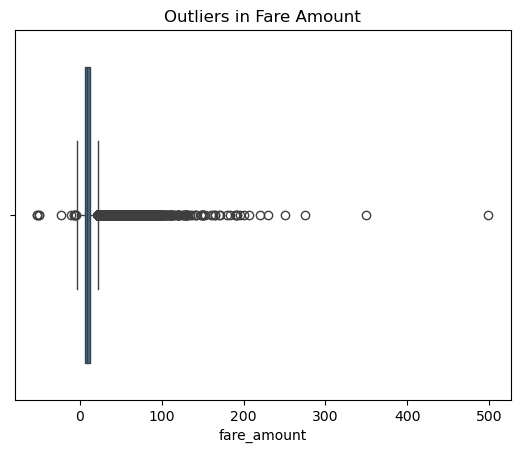

In [10]:
#5. analyse target variable(Fare amount)

#plot histogram to understand distribution
plt.figure()
plt.hist(df['fare_amount'],bins=50)
plt.title("Fare amount Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.show()


#6. Detect Outliers using Boxplot

#boxplot to detect extreme values
plt.figure()
sns.boxplot(x=df['fare_amount'])
plt.title("Outliers in Fare Amount")
plt.show()


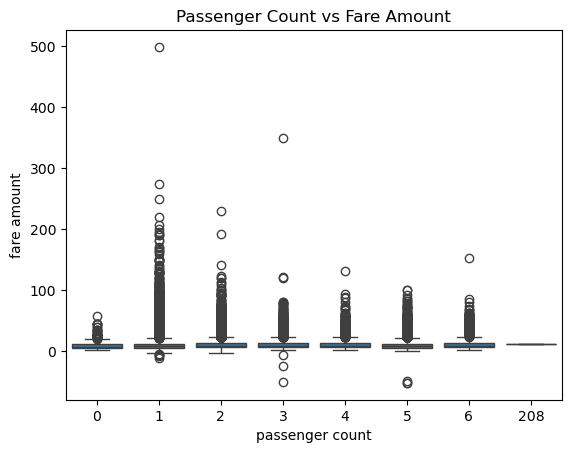

In [11]:
#7. Relationship how passenger count affects fare
plt.figure()
sns.boxplot(x='passenger_count', y='fare_amount', data=df)
plt.title("Passenger Count vs Fare Amount")
plt.xlabel("passenger count")
plt.ylabel("fare amount")
plt.show()

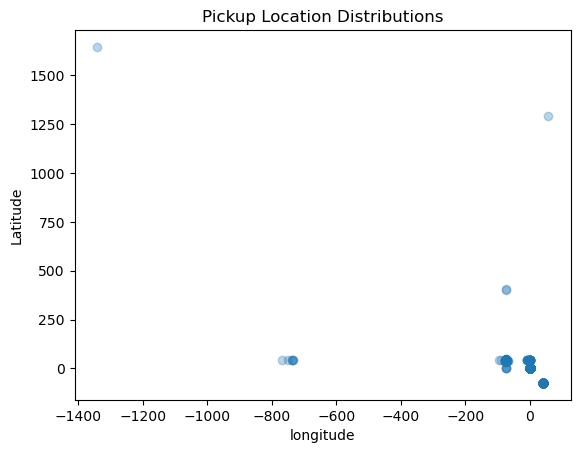

In [12]:
#8. visualize pickup locations

#scatter plot for pickup locations
plt.figure()
plt.scatter(df['pickup_longitude'], df['pickup_latitude'], alpha=0.3)
plt.title("Pickup Location Distributions")
plt.xlabel("longitude")
plt.ylabel("Latitude")
plt.show()

In [13]:
#4. remove irelavant columns

# drop  unnecessary columns like index or  uniqueId
df.drop(['Unnamed: 0', 'key'], axis=1, inplace=True, errors='ignore')


In [14]:
#5. Handle Missing Values

#strategy 1: Drop rows with missing values
df  =  df.dropna()

In [15]:
#6. verify misssing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


In [16]:
#7. Basic validation

#remove invalid values
df  =  df[df['fare_amount']>0]  #remove negative fares
df  =  df[df['passenger_count']> 0]  #remove invalid passenger counts

#display cleaned dataset info
print("\nDataset Information after cleaning:")
print(df.info())


Dataset Information after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 199269 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        199269 non-null  float64
 1   pickup_datetime    199269 non-null  object 
 2   pickup_longitude   199269 non-null  float64
 3   pickup_latitude    199269 non-null  float64
 4   dropoff_longitude  199269 non-null  float64
 5   dropoff_latitude   199269 non-null  float64
 6   passenger_count    199269 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 12.2+ MB
None


In [17]:
# 8 convert datetimme column

#convert pickup datetime into proper  datetime format
df['pickup_datetime'] =  pd.to_datetime(df['pickup_datetime'])

#extract useful time-based features
df['hour'] = df['pickup_datetime'].dt.hour        #hour of ride
df['day'] = df['pickup_datetime'].dt.day          #day of  month
df['month']= df['pickup_datetime'].dt.month       #month
df['weekend'] = df['pickup_datetime'].dt.weekday  #day of week(0=monday)

In [18]:
#9 Create time of Day Feature

#function to classify time of day
def get_time_of_day(hour):
  if 5 <= hour  < 12:
    return "Morning"
  elif 12 <= hour < 17:
    return "Afternoon"
  elif 17 <= hour < 12:
    return "Evening"
  else:
    return "Night"

#apply function
df['time_of_day'] =  df['hour'].apply(get_time_of_day)


In [19]:
#10. calculate distance(Haversine formula)
def haversine(lat1, lon1, lat2, lon2):
  R =  6371 #Earth radius in km

  lat1, lon1, lat2, lon2 = map(np.radians,[lat1,lon1,lat2,lon2])

  dlat =  lat2 -  lat1
  dlon = lon2 - lon1

  a = np.sin(dlat/2)**2 + np.cos(lat1) *  np.cos(lat2) * np.sin(dlon/2)**2
  c = 2 * np.arcsin(np.sqrt(a))

  return R * c

#create distance feature
df['distance_km'] = haversine(
    df['pickup_latitude'],df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

In [20]:
#11. Create distance category feature

def distance_category(dist):
  if dist < 2:
    return "Short"
  elif dist < 5:
    return "Medium"
  else:
    return "Long"

#apply function
df['distance_category'] = df['distance_km'].apply(distance_category)

In [21]:
#12. Encode categorical  preview

#convert categorical features into numeric  using one-hot encoding
df= pd.get_dummies(df, columns=['time_of_day', 'distance_category'], drop_first=True)


In [22]:
#13. Final dataset Preview

print("Final dataset with new features:")
print(df.head())

print("\nUpdated Columns:")
print(df.columns)

Final dataset with new features:
   fare_amount           pickup_datetime  pickup_longitude  pickup_latitude  \
0          7.5 2015-05-07 19:52:06+00:00        -73.999817        40.738354   
1          7.7 2009-07-17 20:04:56+00:00        -73.994355        40.728225   
2         12.9 2009-08-24 21:45:00+00:00        -74.005043        40.740770   
3          5.3 2009-06-26 08:22:21+00:00        -73.976124        40.790844   
4         16.0 2014-08-28 17:47:00+00:00        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  hour  day  month  \
0         -73.999512         40.723217                1    19    7      5   
1         -73.994710         40.750325                1    20   17      7   
2         -73.962565         40.772647                1    21   24      8   
3         -73.965316         40.803349                3     8   26      6   
4         -73.973082         40.761247                5    17   28      8   

   weekend  distance_km  time

In [23]:
# DATA CLEANING


# Remove extreme fare values
df = df[(df['fare_amount'] > 2) & (df['fare_amount'] < 200)]

# Remove invalid passenger count
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]

# Remove invalid coordinates (NYC bounds approx for Uber dataset)
df = df[
    (df['pickup_latitude'].between(40, 42)) &
    (df['pickup_longitude'].between(-75, -72)) &
    (df['dropoff_latitude'].between(40, 42)) &
    (df['dropoff_longitude'].between(-75, -72))
]

In [24]:
# correlation Matrix

#compute correlation  for  numerical features
corr_matrix = df.corr(numeric_only=True)

print("correlation Matrix:")
print(corr_matrix)

correlation Matrix:
                          fare_amount  pickup_longitude  pickup_latitude  \
fare_amount                  1.000000          0.372805        -0.185874   
pickup_longitude             0.372805          1.000000         0.138564   
pickup_latitude             -0.185874          0.138564         1.000000   
dropoff_longitude            0.275360          0.432748         0.182079   
dropoff_latitude            -0.152454          0.165430         0.497545   
passenger_count              0.010837         -0.003597        -0.010756   
hour                        -0.020750          0.021172         0.025796   
day                          0.000827         -0.003444         0.000844   
month                        0.024009          0.005496         0.001525   
weekend                      0.005628         -0.020928        -0.035146   
distance_km                  0.829833          0.405120        -0.169390   
time_of_day_Morning         -0.002261          0.017468         0.05

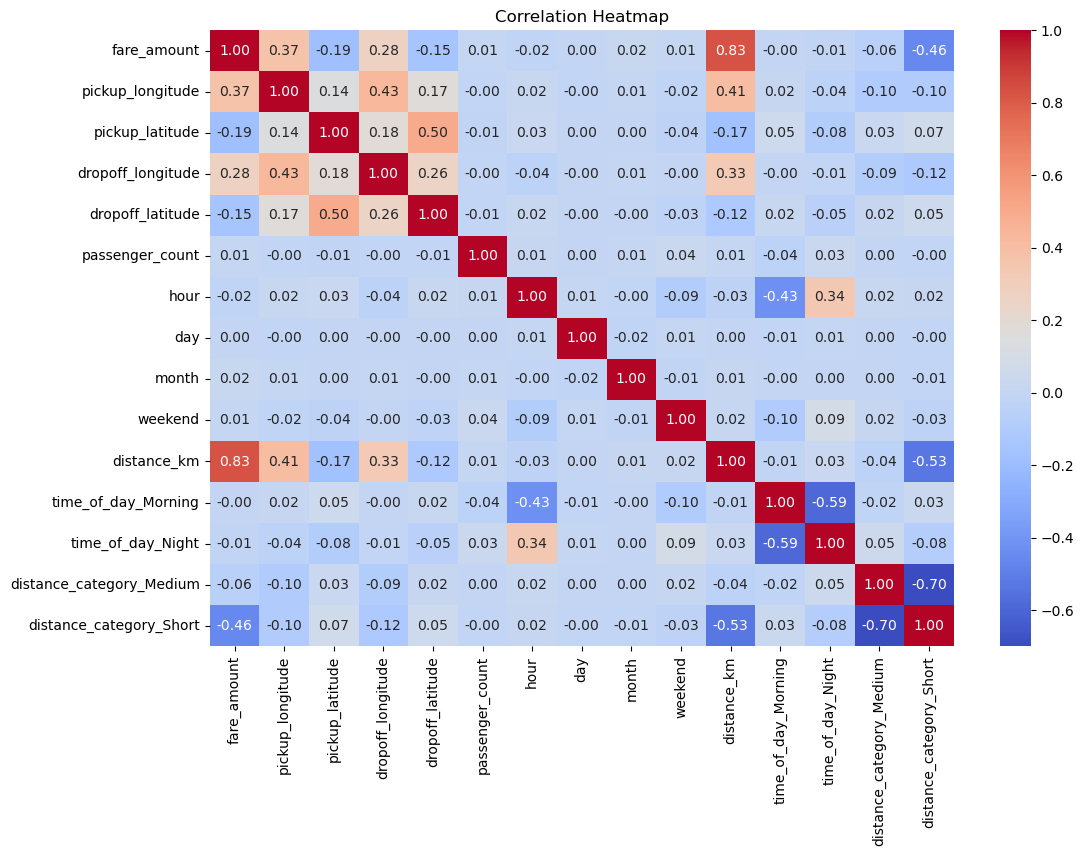

In [25]:
#heat map visualization
plt.figure(figsize=(12,8))   #bigger size for clearity
sns.heatmap(
    corr_matrix,
    annot=True,    #show values
    fmt=".2f",     #2 decimal places
    cmap='coolwarm' #color for heatmap
)
plt.title("Correlation Heatmap")

plt.show()

In [26]:
#correlation with target  variable

#sort  correlation values with fare amount
fare_corr = corr_matrix['fare_amount'].sort_values(ascending=False)

print("Correlation with Fare Amount:")
print(fare_corr)


Correlation with Fare Amount:
fare_amount                 1.000000
distance_km                 0.829833
pickup_longitude            0.372805
dropoff_longitude           0.275360
month                       0.024009
passenger_count             0.010837
weekend                     0.005628
day                         0.000827
time_of_day_Morning        -0.002261
time_of_day_Night          -0.013090
hour                       -0.020750
distance_category_Medium   -0.056213
dropoff_latitude           -0.152454
pickup_latitude            -0.185874
distance_category_Short    -0.456762
Name: fare_amount, dtype: float64


In [27]:
#task: split the dataset

#1 import required libraries
from sklearn.model_selection import train_test_split

#2 Define features(X) and Target (y)
#  X= Independent variables(inputs)
X = df[['passenger_count', 'hour', 'day', 'month', 'distance_km']]

# y  = Dependent variable(target)
y =  df['fare_amount']

In [28]:
#3. Split the Dataset

#split data set into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    #20% data for testing
    random_state=42   #Ensures same split everytime
)

In [29]:
#4. Check the shape  of  the split data

print("training features shape:", X_train.shape)
print("training target shape:", y_train.shape)
print("testing features shape:", X_test.shape)
print("testing target shape:", y_test.shape)

training features shape: (156073, 5)
training target shape: (156073,)
testing features shape: (39019, 5)
testing target shape: (39019,)


In [30]:
#task: data scaling/normalization

#1. import Required library
from sklearn.preprocessing import StandardScaler

#2. Initialize Scalar
scalar =  StandardScaler()

#3. Apply scaling

#fit scalar  only on training data and trasform bth sets
X_train_scaled =  scalar.fit_transform(X_train)

#use sa,e scalar on test data
X_test_scaled =  scalar.transform(X_test)

In [31]:
#4. check results

print("before scaling(First Row):")
print(X_train.iloc[0])

print("after scaling (First Row):")
print(X_train_scaled[0])

before scaling(First Row):
passenger_count    1.000000
hour               5.000000
day                4.000000
month              3.000000
distance_km        1.987201
Name: 112184, dtype: float64
after scaling (First Row):
[-0.52873906 -1.3018303  -1.34822216 -0.95426625 -0.35619444]
